In [1]:
import glob

mask_dir = "/media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output_Jimin_20X/segmentation_3D_masks"
segmentation_3D_mask_list = glob.glob(f"{mask_dir}/**/*_indexed.tif", recursive=True)

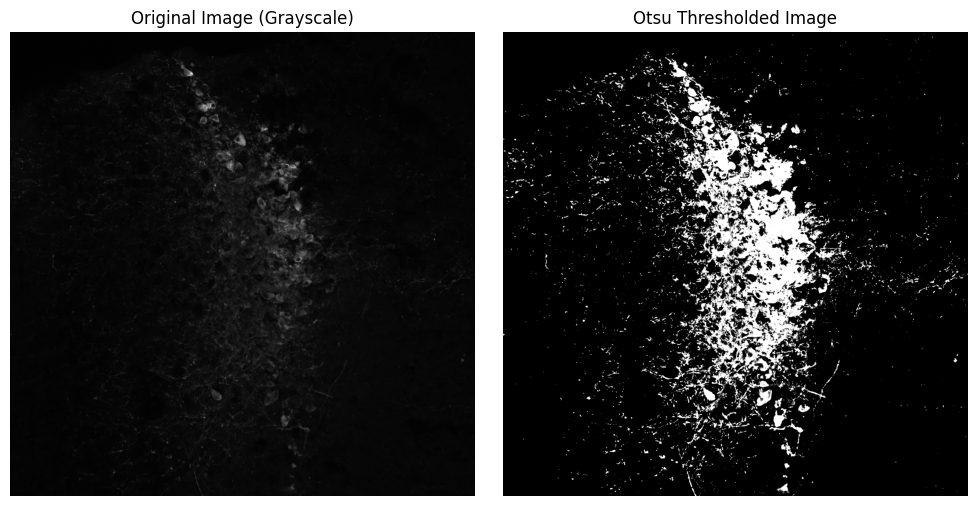

In [36]:
import os
import numpy as np
import tifffile
from skimage.io import imread  # still okay for some tifs
import nd2

import numpy as np

import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu

def read_nd2_channel1(nd2_path: str) -> np.ndarray:
    """
    Load ND2 and return channel 1 (second channel) as a 3D array (Z, Y, X).
    If multiple timepoints, use the first T.
    """
    with nd2.ND2File(nd2_path) as f:
        arr = f.to_dask().compute()   # dask -> numpy
        sizes = f.sizes               # dict, e.g. {'T': 1, 'Z': 24, 'C': 2, 'Y': 512, 'X': 512}
        order = list(f.sizes)         # axis order, e.g. ['T','Z','C','Y','X']

    axis_map = {ax: i for i, ax in enumerate(order)}

    # pick first timepoint if T exists
    if "T" in axis_map:
        arr = np.take(arr, indices=0, axis=axis_map["T"])

    # pick channel 1 (second channel) if C exists
    if "C" in axis_map:
        arr = np.take(arr, indices=1, axis=axis_map["C"])

    return arr

# bases
mask_base = "/media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output_Jimin_20X/segmentation_3d"
original_img_base = "/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images"

for mask_path in segmentation_3D_mask_list[:1]:
    # read the 3D mask tif
    colored_mask = tifffile.imread(mask_path)

    mask_base = "/media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output_Jimin_20X/segmentation_3D_masks"
    original_img_base = "/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/"
    original_img_path = os.path.dirname(mask_path.replace(mask_base, original_img_base)) + ".nd2"
    original_img = read_nd2_channel1(original_img_path)


    # Apply Otsu's threshold
    otsu_thresh_original = threshold_otsu(original_img)
    binary_original_img = original_img > otsu_thresh_original

    # Display the original image and Otsu thresholded image
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(original_img[0], cmap='gray')
    axes[0].set_title("Original Image (Grayscale)")
    axes[0].axis('off')

    axes[1].imshow(binary_original_img[0], cmap='gray')
    axes[1].set_title("Otsu Thresholded Image")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()


In [2]:
import os
import numpy as np
import tifffile
import nd2
from skimage.filters import threshold_otsu
from skimage.measure import regionprops


def read_nd2_channel1(nd2_path: str) -> np.ndarray:
    """
    Load ND2 and return channel 1 (second channel) as a 3D array (Z, Y, X).
    If multiple timepoints, use the first T.
    """
    with nd2.ND2File(nd2_path) as f:
        arr = f.to_dask().compute()   # load into numpy
        sizes = f.sizes               # dict, e.g. {'T': 1, 'Z': 24, 'C': 2, 'Y': 512, 'X': 512}
        order = list(f.sizes)         # axis order, e.g. ['T','Z','C','Y','X']

    axis_map = {ax: i for i, ax in enumerate(order)}

    # pick first timepoint if T exists
    if "T" in axis_map:
        arr = np.take(arr, indices=0, axis=axis_map["T"])

    # pick channel 1 (second channel) if C exists
    if "C" in axis_map:
        arr = np.take(arr, indices=1, axis=axis_map["C"])

    return arr  # shape (Z, Y, X)


def remove_cells_by_otsu(colored_mask: np.ndarray, original_img: np.ndarray, min_overlap: float = 0.5) -> np.ndarray:
    """
    Remove cells from `colored_mask` if less than `min_overlap` of their pixels
    fall in the Otsu foreground region of `original_img`.

    Parameters
    ----------
    colored_mask : 3D ndarray (Z,Y,X)
        Labeled mask with cell IDs.
    original_img : 3D ndarray (Z,Y,X)
        Intensity image used for Otsu thresholding.
    min_overlap : float
        Minimum fraction of a cell’s pixels that must be above threshold to keep it.
    """
    # 1. Compute global Otsu threshold
    otsu_thresh = threshold_otsu(original_img)
    print(f"Global Otsu threshold: {otsu_thresh:.3f}")
    foreground = original_img > otsu_thresh

    # 2. Initialize cleaned mask
    cleaned = colored_mask.copy()

    # 3. Iterate over cells
    for region in regionprops(colored_mask):
        cell_id = region.label
        coords = tuple(region.coords.T)  # z,y,x indices of this cell

        overlap_count = np.count_nonzero(foreground[coords])
        frac_overlap = overlap_count / region.area

        if frac_overlap < min_overlap:
            cleaned[coords] = 0  # remove this cell
            # print(f"Removed cell {cell_id}: overlap={frac_overlap:.2f}")
        else:
            # print(f"Kept cell {cell_id}: overlap={frac_overlap:.2f}")
            pass

    return cleaned






In [3]:
import os
import tifffile
import numpy as np
from multiprocessing import Pool, cpu_count
from tqdm import tqdm

def reindex_mask(mask: np.ndarray) -> np.ndarray:
    """
    Reindex the mask so that the labels start from 1 and are consecutive.
    """
    unique_labels = np.unique(mask)
    reindex_map = {label: idx for idx, label in enumerate(unique_labels) if label != 0}
    reindexed_mask = np.zeros_like(mask, dtype=np.uint16)

    for label, new_label in reindex_map.items():
        reindexed_mask[mask == label] = new_label + 1  # start from 1

    return reindexed_mask


def process_mask(mask_path):
    try:
        # Directories
        mask_base = "/media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output_Jimin_20X/segmentation_3D_masks"
        original_img_base = "/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images"

        # Read 3D masks
        indexed_mask = tifffile.imread(mask_path)
        colored_mask_path = mask_path.replace("_indexed.tif", "_color.tif")

        colored_mask = tifffile.imread(colored_mask_path)
        save_indexed_path = mask_path.replace("segmentation_3D_masks", "cleaned_3D_masks").replace("_indexed.tif", "_indexed_cleaned.tif")
        save_colored_path = colored_mask_path.replace("segmentation_3D_masks", "cleaned_3D_masks").replace("_color.tif", "_color_cleaned.tif")

        save_dir = os.path.dirname(save_indexed_path)
        if not os.path.exists(save_dir):
            os.makedirs(save_dir)
        else: 
            print("⚠️ Cleaned mask already exists, skipping:", save_indexed_path)
            return

        # Build corresponding ND2 path
        original_img_path = os.path.dirname(mask_path.replace(mask_base, original_img_base)) + ".nd2"
        print("Mask file:", mask_path)
        print("ND2 file :", original_img_path)

        if os.path.exists(original_img_path):
            original_img = read_nd2_channel1(original_img_path)
            print("Original image shape:", original_img.shape)
            print("Mask shape:", indexed_mask.shape)

            cleaned_indexed_mask = remove_cells_by_otsu(indexed_mask, original_img, min_overlap=0.5)
            print("Cleaned mask shape:", cleaned_indexed_mask.shape)

            # Reindex
            cleaned_indexed_mask = reindex_mask(cleaned_indexed_mask)

            # Update colored mask background
            background = (cleaned_indexed_mask == 0)
            cleaned_colored_mask = colored_mask.copy()
            cleaned_colored_mask[background] = [0, 0, 0]

        else:
            print("⚠️ ND2 file not found:", original_img_path)
            return

        # Save outputs
        save_indexed_path = mask_path.replace("segmentation_3D_masks", "cleaned_3D_masks").replace("_indexed.tif", "_indexed_cleaned.tif")
        save_colored_path = colored_mask_path.replace("segmentation_3D_masks", "cleaned_3D_masks").replace("_color.tif", "_color_cleaned.tif")

        os.makedirs(os.path.dirname(save_indexed_path), exist_ok=True)
        tifffile.imwrite(save_indexed_path, cleaned_indexed_mask.astype(np.uint16))
        tifffile.imwrite(save_colored_path, cleaned_colored_mask.astype(np.uint8))

        print("✅ Saved cleaned indexed mask to:", save_indexed_path)
        print("✅ Saved cleaned colored mask to:", save_colored_path)

    except Exception as e:
        print(f"❌ Error processing {mask_path}: {e}")


# === Example usage ===
if __name__ == "__main__":
    mask_base = "/media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output_Jimin_20X/segmentation_3D_masks"
    save_dir = mask_base.replace("segmentation_3D_masks", "cleaned_3D_masks")
    os.makedirs(save_dir, exist_ok=True)

    # Assuming you already have this list
    # segmentation_3D_mask_list = [...]

    n_workers = max(1, 32)  # leave a bit of headroom
    with Pool(processes=n_workers) as pool:
        list(tqdm(pool.imap(process_mask, segmentation_3D_mask_list), total=len(segmentation_3D_mask_list)))
        pool.map(process_mask, segmentation_3D_mask_list)


  0%|          | 0/64 [00:00<?, ?it/s]

Mask file: /media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output_Jimin_20X/segmentation_3D_masks/PS19 Mice/6 Months/181/181 Slide 1 Section C3/181 Slide 1 Section C3_3D.tif_indexed.tif
ND2 file : /media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/PS19 Mice/6 Months/181/181 Slide 1 Section C3.nd2
⚠️ Cleaned mask already exists, skipping: /media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output_Jimin_20X/cleaned_3D_masks/PS19 Mice/9 Months/164/164 Slide 2 Section A1/164 Slide 2 Section A1_3D.tif_indexed_cleaned.tif


  2%|▏         | 1/64 [00:00<00:10,  5.84it/s]

Mask file: /media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output_Jimin_20X/segmentation_3D_masks/PS19 Mice/6 Months/179/179 Slide 2 Section A2/179 Slide 2 Section A2_3D.tif_indexed.tif
ND2 file : /media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/PS19 Mice/6 Months/179/179 Slide 2 Section A2.nd2
Mask file: /media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output_Jimin_20X/segmentation_3D_masks/PS19 Mice/6 Months/181/181 Slide 1 Section A3/181 Slide 1 Section A3_3D.tif_indexed.tif
ND2 file : /media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/PS19 Mice/6 Months/181/181 Slide 1 Section A3.nd2
⚠️ Cleaned mask already exists, skipping: /media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output_Jimin_20X/cleaned_3D_masks/PS19 Mice/9 Months/164/164 Slide 2 Section D1/164 Slide 2 Section D1_3D.tif_indexed_cleaned.tif
⚠️ Cleaned mask

  3%|▎         | 2/64 [00:09<05:58,  5.77s/it]

...

  6%|▋         | 4/64 [00:12<02:51,  2.85s/it]

✅ Saved cleaned indexed mask to: /media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output_Jimin_20X/cleaned_3D_masks/PS19 Mice/9 Months/139/139 Slide 2 Section D2/139 Slide 2 Section D2_3D.tif_indexed_cleaned.tif
✅ Saved cleaned colored mask to: /media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output_Jimin_20X/cleaned_3D_masks/PS19 Mice/9 Months/139/139 Slide 2 Section D2/139 Slide 2 Section D2_3D.tif_color_cleaned.tif


100%|██████████| 64/64 [00:13<00:00,  4.64it/s]

⚠️ Cleaned mask already exists, skipping: /media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output_Jimin_20X/cleaned_3D_masks/PS19 Mice/6 Months/179/179 Slide 2 Section A2/179 Slide 2 Section A2_3D.tif_indexed_cleaned.tif
⚠️ Cleaned mask already exists, skipping: ⚠️ Cleaned mask already exists, skipping:/media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output_Jimin_20X/cleaned_3D_masks/PS19 Mice/6 Months/181/181 Slide 1 Section C3/181 Slide 1 Section C3_3D.tif_indexed_cleaned.tif
 /media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output_Jimin_20X/cleaned_3D_masks/PS19 Mice/9 Months/164/164 Slide 2 Section D1/164 Slide 2 Section D1_3D.tif_indexed_cleaned.tif
⚠️ Cleaned mask already exists, skipping: /media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output_Jimin_20X/cleaned_3D_masks/PS19 Mice/6 Months/181/181 Slide 1 Section C2/181 Sl

/media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output_Jimin_20X/cleaned_3D_masks/PS19 Mice/6 Months/153/153 Slide 2 Section B2/153 Slide 2 Section B2_3D.tif_indexed_cleaned.tif⚠️ Cleaned mask already exists, skipping: 
/media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output_Jimin_20X/cleaned_3D_masks/PS19 Mice/9 Months/164/164 Slide 2 Section C1/164 Slide 2 Section C1_3D.tif_indexed_cleaned.tif
⚠️ Cleaned mask already exists, skipping: /media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output_Jimin_20X/cleaned_3D_masks/PS19 Mice/6 Months/178/178 Slide 1 Section D2/178 Slide 1 Section D2_3D.tif_indexed_cleaned.tif
⚠️ Cleaned mask already exists, skipping: ⚠️ Cleaned mask already exists, skipping:/media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output_Jimin_20X/cleaned_3D_masks/PS19 Mice/6 Months/181/181 Slide 1 Section D2/181 Sli

In [5]:
img_list = glob.glob("/media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output_Jimin_20X/cleaned_3D_masks/**/*.tif", recursive=True)
print(len(img_list), "cleaned 3D masks found.")

110 cleaned 3D masks found.


In [8]:
img_list = glob.glob("/media/core/core_operations/ImageAnalysisScratch/Schwarz/Jimin/20X Images/Control Mice/6 Months/**/*.nd2", recursive=True)
print(len(img_list), "ND2 files found.")

25 ND2 files found.


Image shape: (2394, 2394)


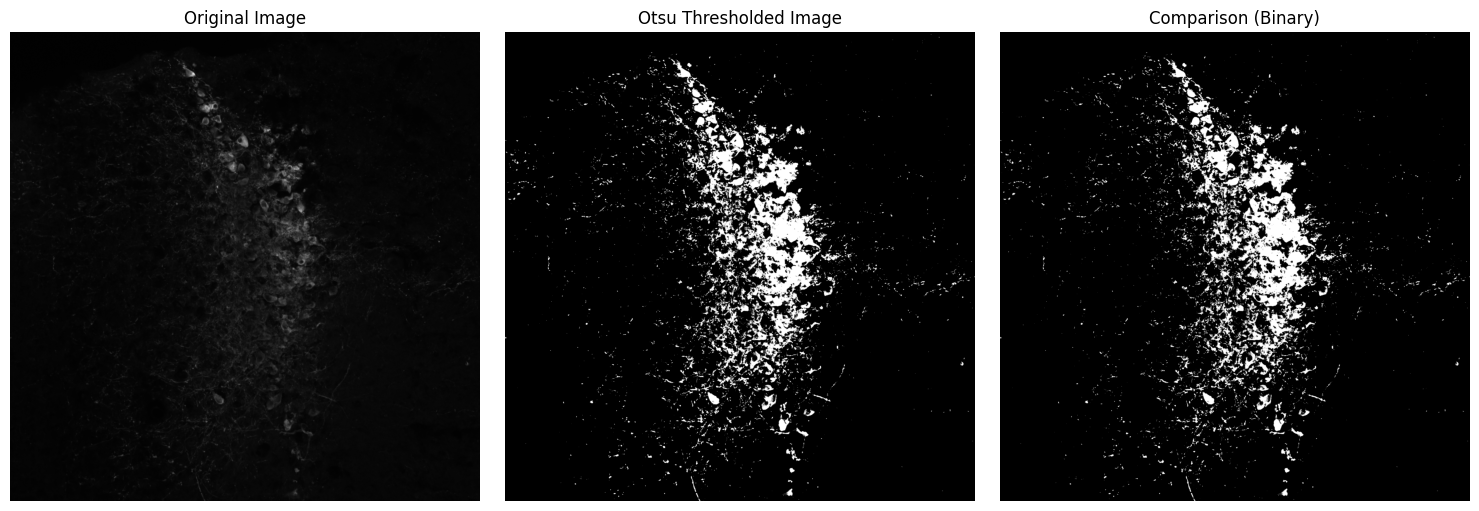

In [2]:
from skimage.io import imread, imsave
from skimage.filters import threshold_otsu
from skimage.color import rgb2gray
from skimage.util import img_as_ubyte

img_path = "/media/core/core_operations/ImageAnalysis/Core/Haoran/core_projects/multi-scale-cellpose/output_Jimin_20X/nd2_planes/164 Slide 2 Section A1/164 Slide 2 Section A1_t0_z0_TH.tif"
img = imread(img_path)

print("Image shape:", img.shape)

import matplotlib.pyplot as plt

# Convert to grayscale if the image is RGB
if img.ndim == 3:
    img_gray = rgb2gray(img)
else:
    img_gray = img

# Apply Otsu's threshold
otsu_thresh = threshold_otsu(img_gray)
binary_img = img_gray > otsu_thresh

# Display the original image, Otsu thresholded image, and comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(binary_img, cmap='gray')
axes[1].set_title("Otsu Thresholded Image")
axes[1].axis('off')

axes[2].imshow(img_as_ubyte(binary_img), cmap='gray')
axes[2].set_title("Comparison (Binary)")
axes[2].axis('off')

plt.tight_layout()
plt.show()